<a href="https://colab.research.google.com/github/Saibhossain/Agentic-framework/blob/main/LLm_workflow_in_Langgraph_gimini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [6]:
!pip install langchain
!pip install langgraph
!pip install langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.2 MB/s eta 0:00:00


# LLM v1

In [8]:
from langgraph import graph
import os
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()


# Get the API key from Colab's user data and set it as an environment variable
os.environ['GOOGLE_API_KEY'] = userdata.get('google_api')

model = init_chat_model("google_genai:gemini-2.5-flash-lite")

class LLMstate(TypedDict):
    question: str
    answer: str

In [9]:
def llm_qa(state: LLMstate) -> LLMstate:

    question = state["question"]
    prompt = f"Answer the following question: {question}"
    answer = model.invoke(prompt).content
    state["answer"] = answer

    return state

In [10]:
graph = StateGraph(LLMstate)

In [11]:
graph.add_node('llm_qa', llm_qa)


graph.add_edge(START,  'llm_qa')
graph.add_edge('llm_qa', END)


workflow = graph.compile()

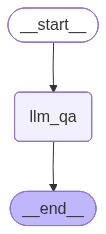

In [12]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [13]:
initial_satate = {'question': 'How far is moon from the earth?'}

final_satae= workflow.invoke(initial_satate)

print(final_satae)

{'question': 'How far is moon from the earth?', 'answer': "The average distance between the Earth and the Moon is **384,400 kilometers (238,900 miles)**.\n\nIt's important to note that this is an **average** distance. The Moon's orbit around the Earth is not a perfect circle, but rather an ellipse. This means the distance varies:\n\n*   **Perigee:** The point where the Moon is closest to Earth, approximately **363,300 kilometers (225,700 miles)**.\n*   **Apogee:** The point where the Moon is farthest from Earth, approximately **405,500 kilometers (251,900 miles)**."}


In [14]:
print(final_satae['answer'])

The average distance between the Earth and the Moon is **384,400 kilometers (238,900 miles)**.

It's important to note that this is an **average** distance. The Moon's orbit around the Earth is not a perfect circle, but rather an ellipse. This means the distance varies:

*   **Perigee:** The point where the Moon is closest to Earth, approximately **363,300 kilometers (225,700 miles)**.
*   **Apogee:** The point where the Moon is farthest from Earth, approximately **405,500 kilometers (251,900 miles)**.
